## Задача baseline-анализа

Задача базового эмпирического анализа заключается в том, чтобы оценить способность традиционных финансовых коэффициентов прогнозировать финансовый дистресс компаний сектора недвижимости.

Для этого необходимо:

 - Сформировать панельный датасет публичных компаний сектора недвижимости из выбранных стран за период 2010–2024 гг.

 - Определить состояние финансового дистресса компаний на основе финансовых показателей, отражающих способность обслуживать долговые обязательства и генерировать операционные денежные потоки.

 - Сконструировать набор финансовых коэффициентов, характеризующих:

1) долговую нагрузку,

2) ликвидность,

3) прибыльность,

4) динамику выручки.

 - Построить базовую эконометрическую модель (logistic regression) для оценки вероятности перехода компании в состояние финансового дистресса в следующем периоде.

 - Оценить качество прогноза базовой модели с использованием стандартных метрик классификации, включая:

1) ROC-кривую,

2) AUC,

3) матрицу ошибок.

Проанализировать экономическую интерпретацию коэффициентов, чтобы определить, какие финансовые характеристики наиболее тесно связаны с вероятностью возникновения дистресса.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/DmitryTeb/Real-Estate/main/finance_data.xlsx"

df = pd.read_excel(url)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (3240, 19)

Columns:
['Company Name', 'Day Close Price Latest', 'Shares Outstanding Latest', 'Market Capitalization Latest', 'FY Total Current Assets ', 'FY Total Assets ', 'FY Total Current Liabilities ', 'FY Total Debt ', 'FY Total Equity ', 'FY Total Revenue ', 'FY Interest Expense ', 'FY EBIT ', 'FY Cash from Ops. ', 'Report Year', 'Exchange:Ticker', 'Industry Classifications', 'Geographic Locations', 'Primary Industry', 'Excel Company ID']


,Company Name,Day Close Price Latest,Shares Outstanding Latest,Market Capitalization Latest,FY Total Current Assets,FY Total Assets,FY Total Current Liabilities,FY Total Debt,FY Total Equity,FY Total Revenue,FY Interest Expense,FY EBIT,FY Cash from Ops.,Report Year,Exchange:Ticker,Industry Classifications,Geographic Locations,Primary Industry,Excel Company ID
0,W. P. Carey Inc. (NYSE:WPC),64.36,219.1,14104.2,1450.45,17990.2,1726.16,8871,8134.1,1705.6,-291.26,890.1,1282.32,2025-01-01,NYSE:WPC,Equity Real Estate Investment Trusts (REITs) (...,United States and Canada (Primary),Diversified REITs,IQ24043
1,American Tower Corporation (NYSE:AMT),175.57,468.1,82192.5,2741.8,63190.4,6913.8,44963.9,10355.3,10644.6,-1359.4,4866.1,5464,2025-01-01,NYSE:AMT,Equity Real Estate Investment Trusts (REITs) (...,United States and Canada (Primary),Telecom Tower REITs,IQ24766
2,Boardwalk Real Estate Investment Trust (TSX:BE...,47.41,49,2324.3,165.56,6614.1,1028.15,2874.6,3616.5,467.6,-94.39,260.7,191.06,2025-01-01,TSX:BEI.UN,Equity Real Estate Investment Trusts (REITs) (...,United States and Canada (Primary),Multi-Family Residential REITs,IQ25678
3,Crown Castle Inc. (NYSE:CCI),88.87,435.5,38701,1144,31518,4479,29566,-1635,4264,-972,2086,3057,2025-01-01,NYSE:CCI,Equity Real Estate Investment Trusts (REITs) (...,United States and Canada (Primary),Telecom Tower REITs,IQ27198
4,"Equinix, Inc. (NasdaqGS:EQIX)",766.16,98.2,75226.2,5125,40141,3893,22726,14178,9260,-636,2006,3911,2025-01-01,NasdaqGS:EQIX,Equity Real Estate Investment Trusts (REITs) (...,United States and Canada (Primary),Data Center REITs,IQ28202


In [2]:
print("Unique companies:", df["Company Name"].nunique())
print("Unique years:", df["Report Year"].nunique())

print("\nYears:")
print(sorted(df["Report Year"].unique()))

Unique companies: 270
Unique years: 12

Years:
[Timestamp('2014-01-01 00:00:00'), Timestamp('2015-01-01 00:00:00'), Timestamp('2016-01-01 00:00:00'), Timestamp('2017-01-01 00:00:00'), Timestamp('2018-01-01 00:00:00'), Timestamp('2019-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2021-01-01 00:00:00'), Timestamp('2022-01-01 00:00:00'), Timestamp('2023-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'), Timestamp('2025-01-01 00:00:00')]


In [3]:
df["Year"] = pd.to_datetime(df["Report Year"]).dt.year

print(df["Year"].unique())

[2025 2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014]


In [4]:
df.columns = df.columns.str.strip()
df.columns

Index(['Company Name', 'Day Close Price Latest', 'Shares Outstanding Latest',
       'Market Capitalization Latest', 'FY Total Current Assets',
       'FY Total Assets', 'FY Total Current Liabilities', 'FY Total Debt',
       'FY Total Equity', 'FY Total Revenue', 'FY Interest Expense', 'FY EBIT',
       'FY Cash from Ops.', 'Report Year', 'Exchange:Ticker',
       'Industry Classifications', 'Geographic Locations', 'Primary Industry',
       'Excel Company ID', 'Year'],
      dtype='object')

In [5]:
df.dtypes

Company Name                            object
Day Close Price Latest                  object
Shares Outstanding Latest               object
Market Capitalization Latest            object
FY Total Current Assets                 object
FY Total Assets                         object
FY Total Current Liabilities            object
FY Total Debt                           object
FY Total Equity                         object
FY Total Revenue                        object
FY Interest Expense                     object
FY EBIT                                 object
FY Cash from Ops.                       object
Report Year                     datetime64[ns]
Exchange:Ticker                         object
Industry Classifications                object
Geographic Locations                    object
Primary Industry                        object
Excel Company ID                        object
Year                                     int32
dtype: object

In [6]:
num_cols = [
    'Day Close Price Latest',
    'Shares Outstanding Latest',
    'Market Capitalization Latest',
    'FY Total Current Assets',
    'FY Total Assets',
    'FY Total Current Liabilities',
    'FY Total Debt',
    'FY Total Equity',
    'FY Total Revenue',
    'FY Interest Expense',
    'FY EBIT',
    'FY Cash from Ops.'
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[num_cols].dtypes

Day Close Price Latest          float64
Shares Outstanding Latest       float64
Market Capitalization Latest    float64
FY Total Current Assets         float64
FY Total Assets                 float64
FY Total Current Liabilities    float64
FY Total Debt                   float64
FY Total Equity                 float64
FY Total Revenue                float64
FY Interest Expense             float64
FY EBIT                         float64
FY Cash from Ops.               float64
dtype: object

In [7]:
df[num_cols].isna().sum().sort_values(ascending=False)

Day Close Price Latest          1820
Market Capitalization Latest     327
Shares Outstanding Latest        322
FY Interest Expense              196
FY Cash from Ops.                190
FY Total Equity                  179
FY Total Assets                  179
FY Total Current Liabilities     179
FY Total Debt                    178
FY Total Current Assets          177
FY Total Revenue                 177
FY EBIT                          177
dtype: int64

# Шаг 5 — построение финансовых коэффициентов

### Теперь создадим ключевые финансовые коэффициенты для baseline-модели.

In [8]:
# долговая нагрузка
df["Debt_to_Assets"] = df["FY Total Debt"] / df["FY Total Assets"]

# ликвидность
df["Current_Ratio"] = df["FY Total Current Assets"] / df["FY Total Current Liabilities"]

# прибыльность
df["ROA"] = df["FY EBIT"] / df["FY Total Assets"]

# операционный денежный поток к долгу
df["OCF_to_Debt"] = df["FY Cash from Ops."] / df["FY Total Debt"]

# покрытие процентов
df["Interest_Coverage"] = df["FY EBIT"] / df["FY Interest Expense"]

df[[
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Interest_Coverage"
]].describe()

/opt/anaconda3/envs/xgboost_env/lib/python3.10/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/anaconda3/envs/xgboost_env/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Interest_Coverage
count,3060.000000,3061.000000,3050.000000,3040.000000,3034.000000
mean,8.991840,4.515785,0.870026,NaN,-inf
std,261.535415,46.891134,22.104284,NaN,NaN
min,0.000000,0.018455,-4.721154,-inf,-inf
25%,0.343045,0.627083,0.027348,0.074266,-5.768877
50%,0.437171,1.211880,0.036889,0.108531,-2.992302
75%,0.512304,2.410764,0.050470,0.147552,-1.786155
max,9665.000000,1770.615385,727.000000,inf,492.327586


## Шаг 6 — очистка коэффициентов

Сейчас нужно:

заменить inf и -inf на NaN

при желании ограничить экстремальные значения winsorization/clip

In [9]:
import numpy as np

ratio_cols = [
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Interest_Coverage"
]

df[ratio_cols] = df[ratio_cols].replace([np.inf, -np.inf], np.nan)

df[ratio_cols].describe()

,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Interest_Coverage
count,3060.000000,3061.000000,3050.000000,3022.000000,3033.000000
mean,8.991840,4.515785,0.870026,4.538087,-6.297442
std,261.535415,46.891134,22.104284,231.863263,42.472056
min,0.000000,0.018455,-4.721154,-37.900413,-2086.229508
25%,0.343045,0.627083,0.027348,0.074252,-5.753425
50%,0.437171,1.211880,0.036889,0.108225,-2.989672
75%,0.512304,2.410764,0.050470,0.146961,-1.784232
max,9665.000000,1770.615385,727.000000,12737.600000,492.327586


In [10]:
for col in ratio_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

df[ratio_cols].describe()

,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Interest_Coverage
count,3060.000000,3061.000000,3050.000000,3022.000000,3033.000000
mean,0.434487,2.643410,0.040220,0.131620,-5.047707
std,0.154666,5.366884,0.025046,0.163565,6.693626
min,0.009895,0.072890,-0.020566,-0.140758,-47.411317
25%,0.343045,0.627083,0.027348,0.074252,-5.753425
50%,0.437171,1.211880,0.036889,0.108225,-2.989672
75%,0.512304,2.410764,0.050470,0.146961,-1.784232
max,0.913009,42.726807,0.156597,1.364111,3.054163


In [11]:
df["Interest_Coverage"] = df["FY EBIT"] / df["FY Interest Expense"].abs()

In [12]:
df["Distress"] = (df["Interest_Coverage"] < 1).astype(int)

df["Distress"].value_counts()

Distress
0    2945
1     295
Name: count, dtype: int64

In [13]:
df["Distress"].value_counts(normalize=True)

Distress
0    0.908951
1    0.091049
Name: proportion, dtype: float64

# Шаг 8 — формирование target (t+1)

### Модель должна предсказывать:

### 𝐷𝑖𝑠𝑡𝑟𝑒𝑠𝑠_(𝑡+1)

### используя финансовые коэффициенты из периода t.

### Для этого нужно сдвинуть distress на один год вперёд внутри каждой компании.

In [14]:
df = df.sort_values(["Company Name", "Year"])

df["Distress_next_year"] = df.groupby("Company Name")["Distress"].shift(-1)

df[["Company Name","Year","Distress","Distress_next_year"]].head(10)

,Company Name,Year,Distress,Distress_next_year
3185,AEON REIT Investment Corporation (TSE:3292),2014,0,0.0
2915,AEON REIT Investment Corporation (TSE:3292),2015,0,0.0
2645,AEON REIT Investment Corporation (TSE:3292),2016,0,0.0
2375,AEON REIT Investment Corporation (TSE:3292),2017,0,0.0
2105,AEON REIT Investment Corporation (TSE:3292),2018,0,0.0
1835,AEON REIT Investment Corporation (TSE:3292),2019,0,0.0
1565,AEON REIT Investment Corporation (TSE:3292),2020,0,0.0
1295,AEON REIT Investment Corporation (TSE:3292),2021,0,0.0
1025,AEON REIT Investment Corporation (TSE:3292),2022,0,0.0
755,AEON REIT Investment Corporation (TSE:3292),2023,0,0.0


In [15]:
df = df.sort_values(["Company Name", "Year"])

df["Distress_next_year"] = df.groupby("Company Name")["Distress"].shift(-1)

df[["Company Name","Year","Distress","Distress_next_year"]].head(10)

,Company Name,Year,Distress,Distress_next_year
3185,AEON REIT Investment Corporation (TSE:3292),2014,0,0.0
2915,AEON REIT Investment Corporation (TSE:3292),2015,0,0.0
2645,AEON REIT Investment Corporation (TSE:3292),2016,0,0.0
2375,AEON REIT Investment Corporation (TSE:3292),2017,0,0.0
2105,AEON REIT Investment Corporation (TSE:3292),2018,0,0.0
1835,AEON REIT Investment Corporation (TSE:3292),2019,0,0.0
1565,AEON REIT Investment Corporation (TSE:3292),2020,0,0.0
1295,AEON REIT Investment Corporation (TSE:3292),2021,0,0.0
1025,AEON REIT Investment Corporation (TSE:3292),2022,0,0.0
755,AEON REIT Investment Corporation (TSE:3292),2023,0,0.0


# Шаг 9 — формирование выборки модели

### Теперь выбираем объясняющие переменные baseline-модели.

In [16]:
# сортируем панель
df = df.sort_values(["Company Name", "Year"])

# создаём distress следующего года
df["Distress_next_year"] = df.groupby("Company Name")["Distress"].shift(-1)

# удаляем последние годы компаний (где нет t+1)
df_model = df.dropna(subset=["Distress_next_year"]).copy()

print("Model dataset shape:", df_model.shape)

Model dataset shape: (2970, 27)


In [17]:
features = [
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt"
]

X = df_model[features]
y = df_model["Distress_next_year"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (2970, 4)
y shape: (2970,)


,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt
3185,0.390395,2.791964,0.005922,-0.050865
2915,0.371164,21.095238,0.033121,0.228409
2645,0.368756,1.559678,0.034724,0.164904
2375,0.426843,1.492184,0.032127,0.112607
2105,0.413558,0.635333,0.032799,0.101864


In [18]:
X.isna().sum()

Debt_to_Assets    179
Current_Ratio     178
ROA               189
OCF_to_Debt       217
dtype: int64

# Шаг 10 — обработка пропусков

### Самый простой и корректный baseline-подход — удалить наблюдения с пропусками.

In [19]:
import numpy as np

data = pd.concat([X, y], axis=1)

data = data.dropna()

print("Clean dataset shape:", data.shape)

Clean dataset shape: (2739, 5)


In [20]:
X_clean = data[features]
y_clean = data["Distress_next_year"]

print("X_clean:", X_clean.shape)
print("y_clean:", y_clean.shape)

X_clean: (2739, 4)
y_clean: (2739,)


# EDA анализ

## Шаг 10.1 — описательная статистика коэффициентов

In [21]:
X_clean.describe()

,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt
count,2739.000000,2739.000000,2739.000000,2739.000000
mean,0.435941,2.664663,0.040014,0.131361
std,0.152044,5.348384,0.024521,0.164232
min,0.009895,0.072890,-0.020566,-0.140758
25%,0.343634,0.646799,0.027352,0.074194
50%,0.437357,1.248847,0.036761,0.107892
75%,0.513056,2.447150,0.050194,0.146871
max,0.913009,42.726807,0.156597,1.364111


### Это типичные показатели для REIT и real estate компаний, которые используют высокий leverage.

## Шаг 10.2 — сравнение distress vs non-distress

In [22]:
data_clean = pd.concat([X_clean, y_clean], axis=1)

data_clean.groupby("Distress_next_year")[features].mean()

,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt
Distress_next_year,,,,
0.0,0.429097,2.502396,0.042676,0.136491
1.0,0.502045,4.231772,0.014308,0.081819


### Компании в distress:

#### имеют более высокую долговую нагрузку

#### имеют значительно более низкую прибыльность

#### генерируют меньше операционного денежного потока относительно долга

#### Это соответствует теории финансового дистресса.

## Шаг 10.3 — корреляционная матрица

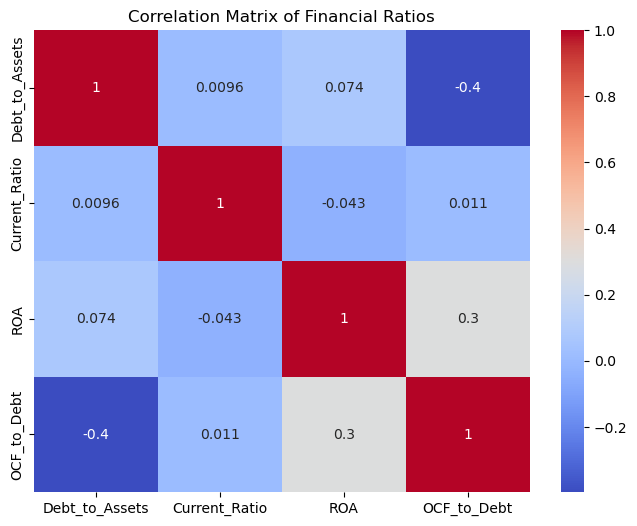

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(X_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Financial Ratios")
plt.show()

### сильной мультиколлинеарности нет

# Шаг 11 — Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_clean, y_clean)

print("Model trained")

Model trained


In [25]:
y_pred = model.predict(X_clean)
y_pred_proba = model.predict_proba(X_clean)[:,1]

In [26]:
from sklearn.metrics import f1_score

f1 = f1_score(y_clean, y_pred)

print("F1-score:", f1)

F1-score: 0.015444015444015444


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_clean, y_pred)

cm

array([[2482,    0],
       [ 255,    2]])

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_clean, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95      2482
         1.0       1.00      0.01      0.02       257

    accuracy                           0.91      2739
   macro avg       0.95      0.50      0.48      2739
weighted avg       0.92      0.91      0.86      2739



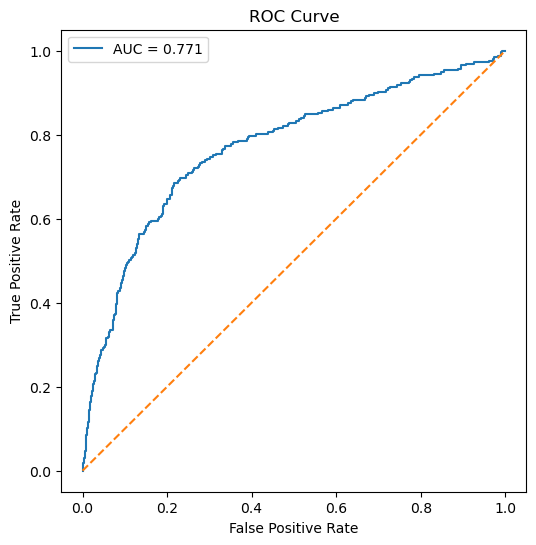

AUC: 0.7707399894022956


In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_clean, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

In [30]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.5, 100)

f1_scores = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_clean, y_pred_t))

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.12878787878787878
Best F1: 0.3903177004538578


In [31]:
class_weight="balanced" # проведем балансировку классов

In [32]:
from sklearn.linear_model import LogisticRegression

logit_balanced = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

logit_balanced.fit(X_clean, y_clean)

print("Model trained")

Model trained


In [33]:
y_pred_proba_bal = logit_balanced.predict_proba(X_clean)[:,1]

In [34]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.5, 100)

f1_scores = []

for t in thresholds:
    pred = (y_pred_proba_bal >= t).astype(int)
    f1_scores.append(f1_score(y_clean, pred))

best_idx = np.argmax(f1_scores)

best_threshold_bal = thresholds[best_idx]
best_f1_bal = f1_scores[best_idx]

print("Best threshold:", best_threshold_bal)
print("Best F1:", best_f1_bal)

Best threshold: 0.5
Best F1: 0.4120819848975189


In [35]:
from sklearn.metrics import roc_auc_score

auc_bal = roc_auc_score(y_clean, y_pred_proba_bal)

print("AUC:", auc_bal)

AUC: 0.8148693942690877


# Следующий шаг — ML benchmark

### Теперь сделаем Random Forest, чтобы сравнить:

###  1) эконометрическую модель

###  2) модель машинного обучения


# Шаг 14 — Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_clean, y_clean)

print("Random Forest trained")

Random Forest trained


In [37]:
y_proba_rf = rf.predict_proba(X_clean)[:,1]

In [38]:
from sklearn.metrics import roc_auc_score

auc_rf = roc_auc_score(y_clean, y_proba_rf)

print("RF AUC:", auc_rf)

RF AUC: 0.9733615102669179


In [39]:
thresholds = np.linspace(0.01, 0.5, 100)

f1_scores = []

for t in thresholds:
    pred = (y_proba_rf >= t).astype(int)
    f1_scores.append(f1_score(y_clean, pred))

best_idx = np.argmax(f1_scores)

best_thr_rf = thresholds[best_idx]
best_f1_rf = f1_scores[best_idx]

print("RF Best threshold:", best_thr_rf)
print("RF Best F1:", best_f1_rf)

RF Best threshold: 0.4851515151515151
RF Best F1: 0.6799387442572741


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.3,
    random_state=42,
    stratify=y_clean
)

print(X_train.shape, X_test.shape)

(1917, 4) (822, 4)


In [41]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,400
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
y_proba_rf = rf.predict_proba(X_test)[:,1]

In [43]:
from sklearn.metrics import roc_auc_score

auc_rf = roc_auc_score(y_test, y_proba_rf)

print("RF AUC:", auc_rf)

RF AUC: 0.8937331125250588


In [44]:
thresholds = np.linspace(0.01,0.5,100)

f1_scores = []

for t in thresholds:
    pred = (y_proba_rf >= t).astype(int)
    f1_scores.append(f1_score(y_test,pred))

best_idx = np.argmax(f1_scores)

best_thr_rf = thresholds[best_idx]
best_f1_rf = f1_scores[best_idx]

print("Best threshold:",best_thr_rf)
print("Best F1:",best_f1_rf)

Best threshold: 0.4901010101010101
Best F1: 0.5560975609756098


In [45]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance

,Feature,Importance
2,ROA,0.582198
3,OCF_to_Debt,0.155635
1,Current_Ratio,0.136384
0,Debt_to_Assets,0.125783


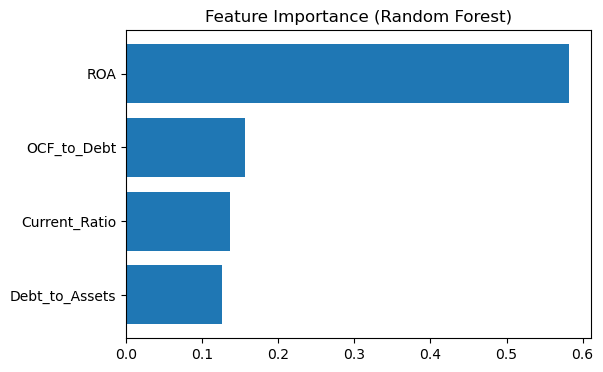

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

In [47]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score

# 1. Сортировка панели
df = df.sort_values(["Company Name", "Year"]).copy()

# 2. Добавляем новые факторы
df["Revenue_Growth"] = df.groupby("Company Name")["FY Total Revenue"].pct_change()
df["Interest_Coverage"] = df["FY EBIT"] / df["FY Interest Expense"].abs()

# 3. Чистим бесконечности
df["Revenue_Growth"] = df["Revenue_Growth"].replace([np.inf, -np.inf], np.nan)
df["Interest_Coverage"] = df["Interest_Coverage"].replace([np.inf, -np.inf], np.nan)

# 4. Если Distress_next_year ещё не создан, создаём
if "Distress_next_year" not in df.columns:
    df["Distress_next_year"] = df.groupby("Company Name")["Distress"].shift(-1)

# 5. Собираем новый набор факторов
features = [
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Revenue_Growth",
    "Interest_Coverage"
]

# 6. Формируем датасет модели и удаляем пропуски
df_model = df.dropna(subset=["Distress_next_year"]).copy()

data = pd.concat(
    [df_model[features], df_model["Distress_next_year"]],
    axis=1
).dropna()

X_clean = data[features]
y_clean = data["Distress_next_year"]

print("New dataset shape:", X_clean.shape)

# 7. Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.3,
    random_state=42,
    stratify=y_clean
)

# 8. Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

# 9. Вероятности и AUC
y_proba_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("RF AUC:", auc_rf)

# 10. Поиск лучшего threshold по F1
thresholds = np.linspace(0.01, 0.5, 100)
f1_scores = []

for t in thresholds:
    pred = (y_proba_rf >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred))

best_idx = np.argmax(f1_scores)
best_thr_rf = thresholds[best_idx]
best_f1_rf = f1_scores[best_idx]

print("Best threshold:", best_thr_rf)
print("Best F1:", best_f1_rf)

# 11. Feature importance
importance = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature importance:")
print(importance)

/var/folders/4t/kvqrshcd14j8vg1sphh7w1vm0000gn/T/ipykernel_2171/4096519709.py:11: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["Revenue_Growth"] = df.groupby("Company Name")["FY Total Revenue"].pct_change()


New dataset shape: (2469, 6)
RF AUC: 0.935989068740803
Best threshold: 0.4802020202020202
Best F1: 0.6888888888888889

Feature importance:
             Feature  Importance
5  Interest_Coverage    0.442018
2                ROA    0.253744
3        OCF_to_Debt    0.100399
1      Current_Ratio    0.077518
4     Revenue_Growth    0.063802
0     Debt_to_Assets    0.062520


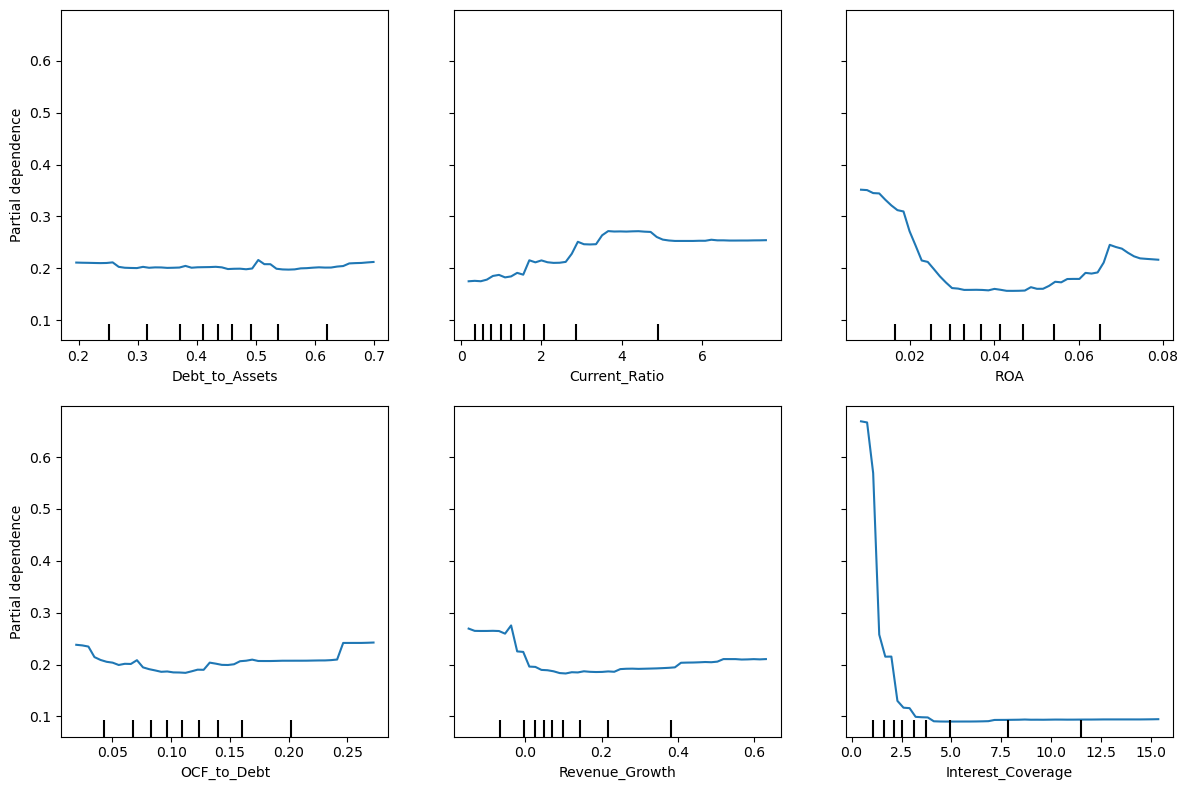

In [48]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = [
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Revenue_Growth",
    "Interest_Coverage"
]

fig, ax = plt.subplots(figsize=(12,8))

PartialDependenceDisplay.from_estimator(
    rf,
    X_clean,
    features,
    grid_resolution=50,
    ax=ax
)

plt.tight_layout()
plt.show()

# XGBoost

In [49]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

print("XGB AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
print("FN (XGB):", cm[1,0])

/opt/anaconda3/envs/xgboost_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [19:56:55] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB AUC: 0.9195291149884381
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.95       670
         1.0       0.54      0.80      0.65        71

    accuracy                           0.92       741
   macro avg       0.76      0.87      0.80       741
weighted avg       0.94      0.92      0.92       741

FN (XGB): 14


# Probit

In [50]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

probit_model = sm.Probit(y_train, X_train_sm).fit()

y_proba_probit = probit_model.predict(X_test_sm)
y_pred_probit = (y_proba_probit > 0.5).astype(int)

print("PROBIT AUC:", roc_auc_score(y_test, y_proba_probit))
print(classification_report(y_test, y_pred_probit))

cm = confusion_matrix(y_test, y_pred_probit)
print("FN (Probit):", cm[1,0])

Optimization terminated successfully.
         Current function value: 0.237882
         Iterations 8
PROBIT AUC: 0.913348749211688
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95       670
         1.0       0.75      0.17      0.28        71

    accuracy                           0.91       741
   macro avg       0.83      0.58      0.62       741
weighted avg       0.90      0.91      0.89       741

FN (Probit): 59


# Lasso Logistic 

In [51]:
lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000
)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
y_proba_lasso = lasso.predict_proba(X_test)[:,1]

print("LASSO AUC:", roc_auc_score(y_test, y_proba_lasso))
print(classification_report(y_test, y_pred_lasso))

cm = confusion_matrix(y_test, y_pred_lasso)
print("FN (Lasso):", cm[1,0])

LASSO AUC: 0.9186672272440614
              precision    recall  f1-score   support

         0.0       0.99      0.80      0.88       670
         1.0       0.32      0.90      0.47        71

    accuracy                           0.81       741
   macro avg       0.65      0.85      0.68       741
weighted avg       0.92      0.81      0.84       741

FN (Lasso): 7


# Threshold optimization 

In [52]:
threshold = 0.3  # попробуй 0.2–0.4

y_pred_custom = (y_proba_xgb > threshold).astype(int)

print("Custom Threshold (XGB)")
print(classification_report(y_test, y_pred_custom))

cm = confusion_matrix(y_test, y_pred_custom)
print("FN (Custom):", cm[1,0])

Custom Threshold (XGB)
              precision    recall  f1-score   support

         0.0       0.98      0.88      0.93       670
         1.0       0.43      0.85      0.57        71

    accuracy                           0.88       741
   macro avg       0.70      0.86      0.75       741
weighted avg       0.93      0.88      0.89       741

FN (Custom): 11


In [53]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=1000, class_weight="balanced")

logit.fit(X_train, y_train)

y_pred_logit = logit.predict(X_test)
y_proba_logit = logit.predict_proba(X_test)[:,1]

In [54]:
results = {
    "Model": ["Logit", "RF", "XGB", "Probit", "Lasso"],
    "AUC": [
        roc_auc_score(y_test, y_proba_logit),
        roc_auc_score(y_test, y_proba_rf),      
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_probit),
        roc_auc_score(y_test, y_proba_lasso),
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

    Model       AUC
0   Logit  0.913139
1      RF  0.935989
2     XGB  0.919529
3  Probit  0.913349
4   Lasso  0.918667


#  Risk Analysis by Region, Industry, and Time 

X_clean shape: (2469, 6)
y_clean shape: (2469,)
df_final created successfully!

 Regional Analysis 
                                    Mean_Probability  Std_Probability  Count  \
Geographic Locations                                                           
Korea, South (Primary)                        0.4269           0.2554     12   
United States and Canada (Primary)            0.2809           0.3106   1406   
United Kingdom (Primary)                      0.1324           0.1882    196   
Germany (Primary)                             0.1297           0.1489     90   
Australia (Primary)                           0.1092           0.1382    269   
Japan (Primary)                               0.0594           0.1028    496   

                                    Predicted_Distress_Count  
Geographic Locations                                          
Korea, South (Primary)                                     6  
United States and Canada (Primary)                       323  
United 

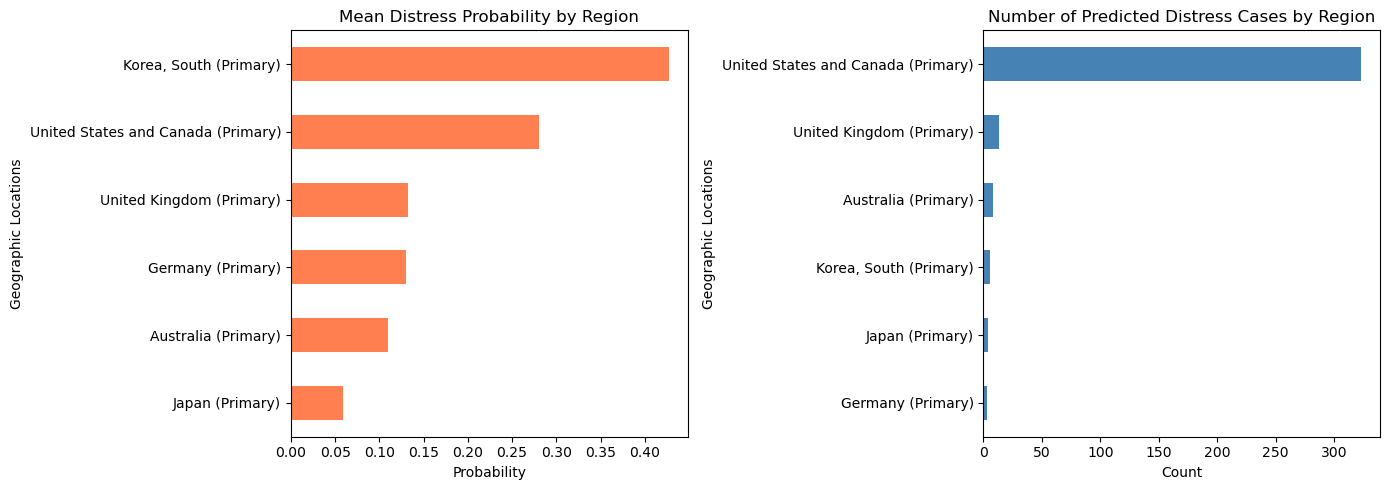


 REIT Type Analysis 
                                 Mean_Probability  Std_Probability  Count  \
Primary Industry                                                            
Single-Family Residential REITs            0.3134           0.2909     50   
Hotel and Resort REITs                     0.2962           0.3211    118   
Real Estate Development                    0.2727           0.2295     89   
Health Care REITs                          0.2550           0.2721    179   
Real Estate Operating Companies            0.2277           0.3038    182   
Other Specialized REITs                    0.2245           0.2375    127   
Timber REITs                               0.2228           0.1815     20   
Multi-Family Residential REITs             0.2151           0.3329    221   
Office REITs                               0.2140           0.2730    322   
Retail REITs                               0.1753           0.2555    410   
Diversified REITs                          0.1704     

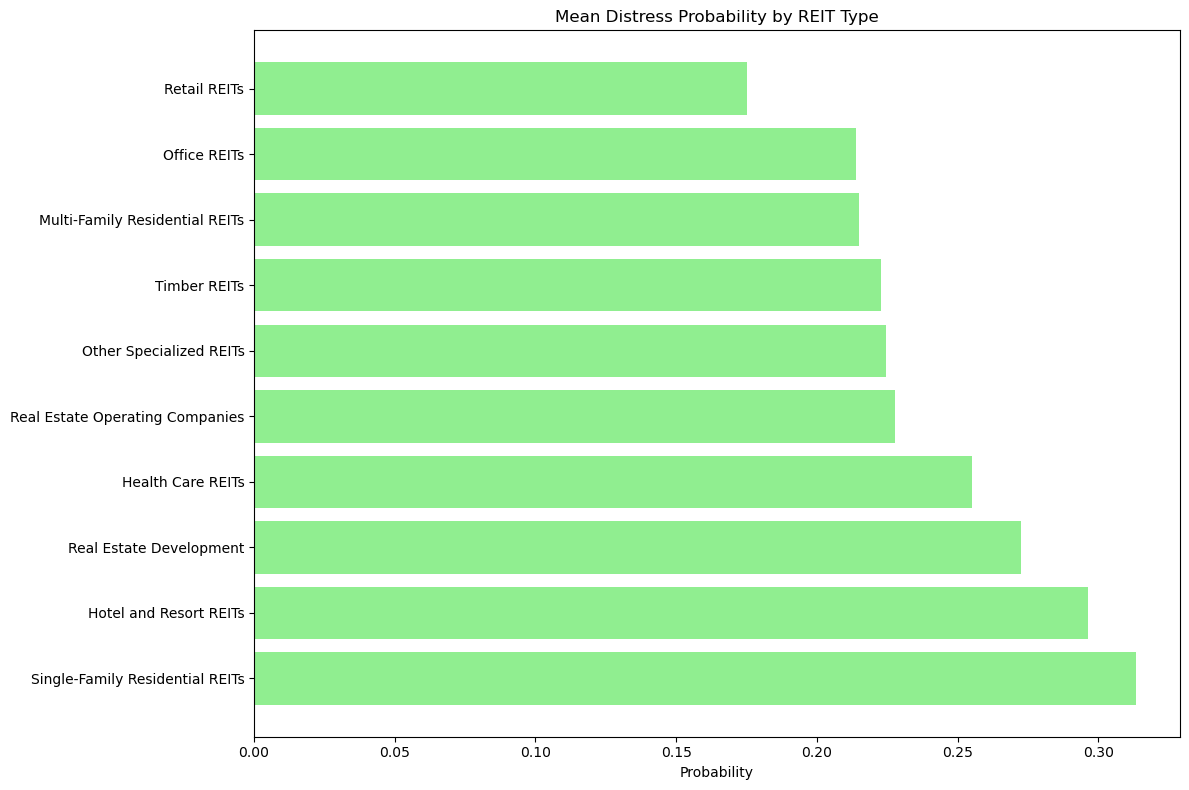


 Yearly Risk Dynamics 
      Mean_Probability  Std_Probability  Predicted_Distress_Count
Year                                                             
2015            0.1782           0.2382                        25
2016            0.1707           0.2216                        25
2017            0.1628           0.2295                        24
2018            0.1638           0.2216                        22
2019            0.2039           0.2664                        40
2020            0.2822           0.3273                        52
2021            0.2217           0.2919                        42
2022            0.1969           0.2712                        35
2023            0.2143           0.2931                        46
2024            0.2161           0.2873                        46


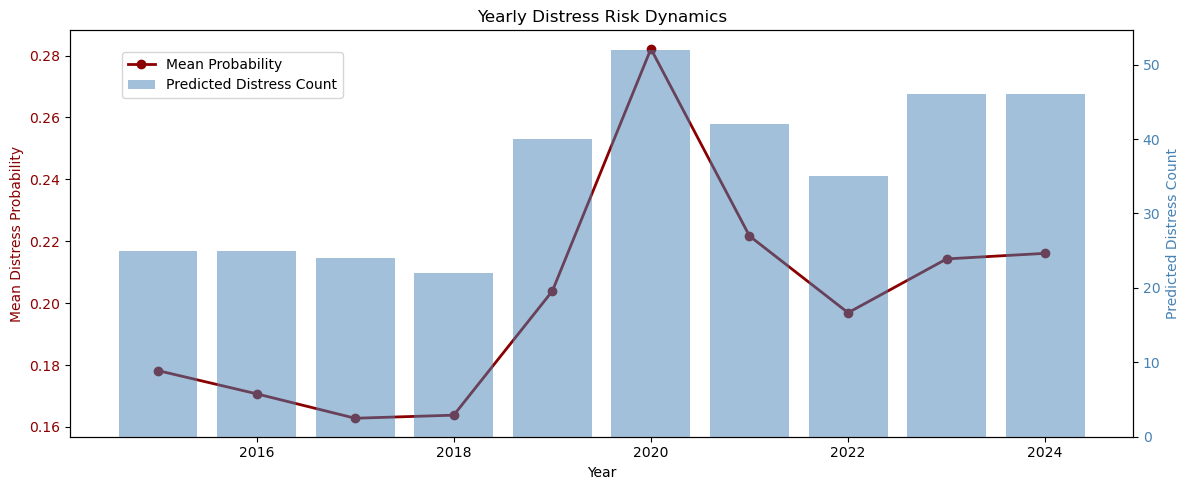


 Top 10 Highest Risk Companies 
                                          Company Name                Primary Industry               Geographic Locations  Year  Forecast_Year  Distress_Probability  Predicted_Distress
          NexPoint Residential Trust, Inc. (NYSE:NXRT)  Multi-Family Residential REITs United States and Canada (Primary)  2021           2022              0.988701                   1
Apartment Investment and Management Company (NYSE:AIV)  Multi-Family Residential REITs United States and Canada (Primary)  2021           2022              0.986731                   1
          NexPoint Residential Trust, Inc. (NYSE:NXRT)  Multi-Family Residential REITs United States and Canada (Primary)  2017           2018              0.981681                   1
Apartment Investment and Management Company (NYSE:AIV)  Multi-Family Residential REITs United States and Canada (Primary)  2020           2021              0.980540                   1
               Kennedy-Wilson Holdings, In

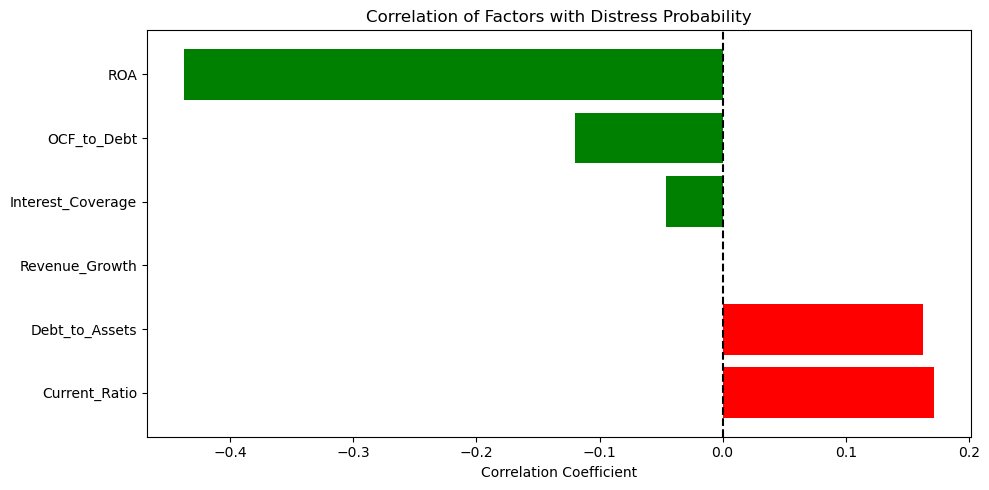

In [55]:

print("X_clean shape:", X_clean.shape if 'X_clean' in dir() else "Not defined")
print("y_clean shape:", y_clean.shape if 'y_clean' in dir() else "Not defined")

if 'df_final' not in dir():
    df_final = df.loc[X_clean.index].copy() if 'df' in dir() and 'X_clean' in dir() else None
    
    if df_final is not None:
        for col in X_clean.columns:
            df_final[col] = X_clean[col]
        
        df_final["Distress_Probability"] = rf.predict_proba(X_clean)[:,1]
        df_final["Predicted_Distress"] = (df_final["Distress_Probability"] >= best_thr_rf).astype(int)
        df_final["Forecast_Year"] = df_final["Year"] + 1
        
        print("df_final created successfully!")
    else:
        print("Cannot create df_final - missing required data")

if 'df_final' in dir() and df_final is not None:
    region_analysis = df_final.groupby("Geographic Locations").agg({
        "Distress_Probability": ["mean", "std", "count"],
        "Predicted_Distress": "sum"
    }).round(4)
    
    region_analysis.columns = ['Mean_Probability', 'Std_Probability', 'Count', 'Predicted_Distress_Count']
    region_analysis = region_analysis.sort_values('Mean_Probability', ascending=False)
    
    print("\n Regional Analysis ")
    print(region_analysis)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    region_analysis['Mean_Probability'].sort_values().plot(kind='barh', ax=ax1, color='coral')
    ax1.set_title('Mean Distress Probability by Region')
    ax1.set_xlabel('Probability')
    
    ax2 = axes[1]
    region_analysis['Predicted_Distress_Count'].sort_values().plot(kind='barh', ax=ax2, color='steelblue')
    ax2.set_title('Number of Predicted Distress Cases by Region')
    ax2.set_xlabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    print("\n REIT Type Analysis ")
    reit_analysis = df_final.groupby("Primary Industry").agg({
        "Distress_Probability": ["mean", "std", "count"],
        "Predicted_Distress": "sum"
    }).round(4)
    
    reit_analysis.columns = ['Mean_Probability', 'Std_Probability', 'Count', 'Predicted_Distress_Count']
    reit_analysis = reit_analysis.sort_values('Mean_Probability', ascending=False)
    print(reit_analysis.head(15))
    
    plt.figure(figsize=(12, 8))
    top_reits = reit_analysis.head(10)
    plt.barh(top_reits.index, top_reits['Mean_Probability'], color='lightgreen')
    plt.title('Mean Distress Probability by REIT Type')
    plt.xlabel('Probability')
    plt.tight_layout()
    plt.show()
    
    print("\n Yearly Risk Dynamics ")
    yearly_analysis = df_final.groupby("Year").agg({
        "Distress_Probability": ["mean", "std"],
        "Predicted_Distress": "sum"
    }).round(4)
    
    yearly_analysis.columns = ['Mean_Probability', 'Std_Probability', 'Predicted_Distress_Count']
    print(yearly_analysis)
    
    fig, ax1 = plt.subplots(figsize=(12, 5))
    
    ax1.plot(yearly_analysis.index, yearly_analysis['Mean_Probability'], 
             marker='o', color='darkred', linewidth=2, label='Mean Probability')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Mean Distress Probability', color='darkred')
    ax1.tick_params(axis='y', labelcolor='darkred')
    
    ax2 = ax1.twinx()
    ax2.bar(yearly_analysis.index, yearly_analysis['Predicted_Distress_Count'], 
            alpha=0.5, color='steelblue', label='Predicted Distress Count')
    ax2.set_ylabel('Predicted Distress Count', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')
    
    plt.title('Yearly Distress Risk Dynamics')
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()
    
    print("\n Top 10 Highest Risk Companies ")
    top_risky = df_final.nlargest(10, 'Distress_Probability')[[
        'Company Name', 'Primary Industry', 'Geographic Locations', 
        'Year', 'Forecast_Year', 'Distress_Probability', 'Predicted_Distress'
    ]]
    print(top_risky.to_string(index=False))
    
    print("\n Correlation with Distress Probability ")
    risk_factors = ['Debt_to_Assets', 'Current_Ratio', 'ROA', 
                   'OCF_to_Debt', 'Revenue_Growth', 'Interest_Coverage']
    
    correlations = {}
    for factor in risk_factors:
        corr = df_final[factor].corr(df_final['Distress_Probability'])
        correlations[factor] = corr
    
    corr_df = pd.DataFrame(list(correlations.items()), columns=['Factor', 'Correlation'])
    corr_df = corr_df.sort_values('Correlation', ascending=False)
    print(corr_df.to_string(index=False))
    
    plt.figure(figsize=(10, 5))
    colors = ['red' if x > 0 else 'green' for x in corr_df['Correlation']]
    plt.barh(corr_df['Factor'], corr_df['Correlation'], color=colors)
    plt.axvline(x=0, color='black', linestyle='--')
    plt.title('Correlation of Factors with Distress Probability')
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()
    
else:
    print("Please ensure X_clean, y_clean, and rf model are available")
    print("Run the earlier cells in the notebook first")

# LLM

In [106]:
import requests
import json
import uuid
import pdfplumber
import os
import numpy as np
import re
import time
from pathlib import Path
from dotenv import load_dotenv

#  Загрузка ключей

env_path = Path('.env')
load_dotenv(dotenv_path=env_path, override=True)

AUTH_KEY = os.getenv("GIGACHAT_AUTH_KEY")
SCOPE = os.getenv("GIGACHAT_SCOPE")

PDF_PATH = "/Users/margarita/Downloads/report/AMERICAN HEALTHCARE REIT 2016.pdf"

# GigaChat Client

class GigaChatClient:
    def __init__(self):
        self.token = None
        self._get_token()
    
    def _get_token(self):
        url = "https://ngw.devices.sberbank.ru:9443/api/v2/oauth"
        headers = {
            "Content-Type": "application/x-www-form-urlencoded",
            "Accept": "application/json",
            "RqUID": str(uuid.uuid4()),
            "Authorization": f"Basic {AUTH_KEY}"
        }
        data = {"scope": SCOPE}
        
        response = requests.post(url, headers=headers, data=data, verify=False)
        if response.status_code == 200:
            self.token = response.json()["access_token"]
            print(" Token получен")
        else:
            raise Exception(response.text)
    
    def chat(self, prompt):
        url = "https://gigachat.devices.sberbank.ru/api/v1/chat/completions"
        headers = {
            "Content-Type": "application/json",
            "Authorization": f"Bearer {self.token}"
        }
        data = {
            "model": "GigaChat",
            "messages": [{"role": "user", "content": prompt}],
            "temperature": 0.2,
            "max_tokens": 1500
        }
        
        response = requests.post(url, headers=headers, json=data, verify=False)
        if response.status_code == 200:
            return response.json()["choices"][0]["message"]["content"]
        else:
            print(response.text)
            return ""

giga = GigaChatClient()

# 🔎 КЛЮЧЕВЫЕ СЛОВА

KEYWORDS = {
    "Liquidity": ["liquidity", "cash flow", "capital resources", "financial condition"],
    "Refinancing": ["debt", "borrowings", "credit facility", "refinancing", "leverage"],
    "Outlook": ["outlook", "future", "strategy", "business overview"],
    "Risk": ["risk factors", "uncertainty", "market risk", "risks"]
}

# СКОР СТРАНИЦЫ

def score_page(text):
    text = text.lower()
    score = 0
    
    if "risk factors" in text:
        score += 3
    if "liquidity" in text:
        score += 2
    if "debt" in text:
        score += 2
    if "cash flow" in text:
        score += 2
    
    return score


#  ПОИСК ЛУЧШИХ СТРАНИЦ

def find_best_pages(pdf_path, top_n=30):
    scored_pages = []

    with pdfplumber.open(pdf_path) as pdf:
        for i, page in enumerate(pdf.pages):
            text = page.extract_text()
            if not text:
                continue

            s = score_page(text)
            if s > 0:
                scored_pages.append((i+1, s))

    scored_pages = sorted(scored_pages, key=lambda x: -x[1])
    best_pages = [p[0] for p in scored_pages[:top_n]]

    return best_pages

#  ЧТЕНИЕ СТРАНИЦ

def read_pages(path, pages):
    text = ""
    with pdfplumber.open(path) as pdf:
        for p in pages:
            if p-1 < len(pdf.pages):
                t = pdf.pages[p-1].extract_text()
                if t:
                    text += t + "\n"
    return text

#  SPLIT TEXT

def split_text(text, size=4000):
    return [text[i:i+size] for i in range(0, len(text), size)]
#  PROMPT

def get_analysis_prompt(text):
    return f"""
You are a financial distress analyst.

Return ONLY JSON:

{{
 "Liquidity": 0 or 1,
 "Refinancing": 0 or 1,
 "Outlook": 0 or 1,
 "Risk": number 0-100
}}

Rules:
- 1 = any risk signal
- detect weak signals
- no explanation

Text:
\"\"\"{text[:6000]}\"\"\"
"""


# PARSE

def parse_response(resp):
    try:
        json_text = re.search(r"\{.*\}", resp, re.DOTALL).group()
        data = json.loads(json_text)
        
        return (
            int(data.get("Liquidity",0)),
            int(data.get("Refinancing",0)),
            int(data.get("Outlook",0)),
            float(data.get("Risk",0))
        )
    except:
        return (0,0,0,0)

#  MAIN

print("\n📄 Processing...\n")

# 1. найти лучшие страницы
pages = find_best_pages(PDF_PATH)
print("📑 Selected pages:", pages[:10], "...")

# 2. прочитать
text = read_pages(PDF_PATH, pages)

# 3. разбить
chunks = split_text(text)[:20]

print("Total chunks:", len(chunks))

# 4. анализ
L, R, O, S = [], [], [], []

for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}/{len(chunks)}")

    resp = giga.chat(get_analysis_prompt(chunk))
    l, r, o, s = parse_response(resp)

    L.append(l)
    R.append(r)
    O.append(o)
    S.append(s)

    time.sleep(1)

#  FINAL RESULT
final = {
    "llm_liquidity": int(np.mean(L) > 0.3),
    "llm_refinancing": int(np.mean(R) > 0.3),
    "llm_outlook": int(np.mean(O) > 0.3),
    "llm_risk_score": np.nanmean(S)
}

print("\n=== FINAL RESULT ===")
print(final)

 Token получен

📄 Processing...

📑 Selected pages: [17, 10, 11, 48, 51, 69, 77, 78, 9, 64] ...
Total chunks: 20
Chunk 1/20
Chunk 2/20
Chunk 3/20
Chunk 4/20
Chunk 5/20
Chunk 6/20
Chunk 7/20
Chunk 8/20
Chunk 9/20
Chunk 10/20
Chunk 11/20
Chunk 12/20
Chunk 13/20
Chunk 14/20
Chunk 15/20
Chunk 16/20
Chunk 17/20
Chunk 18/20
Chunk 19/20
Chunk 20/20

=== FINAL RESULT ===
{'llm_liquidity': 1, 'llm_refinancing': 1, 'llm_outlook': 0, 'llm_risk_score': np.float64(31.8)}


# SHAP analysis
### Показывает как каждый фактор повышает или снижает риск distress на уровне наблюдений

In [ ]:
!pip install shap

In [101]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)

# если SHAP вернул значения для двух классов, берем класс 1
if len(shap_values.values.shape) == 3:
    shap_values_class1 = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=shap_values.base_values[:, 1],
        data=shap_values.data,
        feature_names=shap_values.feature_names
    )
else:
    shap_values_class1 = shap_values

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_class1, max_display=10, show=False)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'shap'

In [ ]:
from sklearn.metrics import confusion_matrix

# прогноз по лучшему порогу
y_pred_rf = (y_proba_rf >= best_thr_rf).astype(int)

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTrue Negatives:", TN)
print("False Positives (Type I error):", FP)
print("False Negatives (Type II error):", FN)
print("True Positives:", TP)

# доли ошибок
type1_rate = FP / (FP + TN)
type2_rate = FN / (FN + TP)

print("\nType I error rate:", type1_rate)
print("Type II error rate:", type2_rate)

Confusion matrix:
[[623  47]
 [  9  62]]

True Negatives: 623
False Positives (Type I error): 47
False Negatives (Type II error): 9
True Positives: 62

Type I error rate: 0.07014925373134329
Type II error rate: 0.1267605633802817


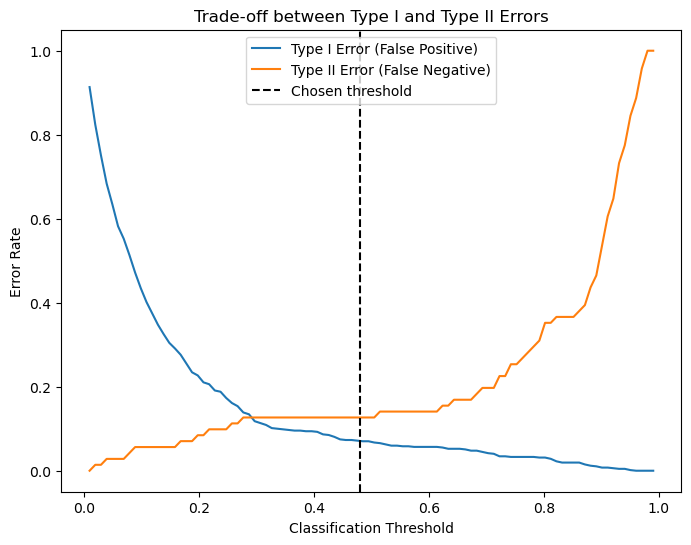

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.01, 0.99, 100)

type1_errors = []
type2_errors = []

for t in thresholds:
    
    y_pred = (y_proba_rf >= t).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    TN, FP, FN, TP = cm.ravel()
    
    type1 = FP / (FP + TN)
    type2 = FN / (FN + TP)
    
    type1_errors.append(type1)
    type2_errors.append(type2)

plt.figure(figsize=(8,6))

plt.plot(thresholds, type1_errors, label="Type I Error (False Positive)")
plt.plot(thresholds, type2_errors, label="Type II Error (False Negative)")

plt.axvline(best_thr_rf, linestyle="--", color="black", label="Chosen threshold")

plt.xlabel("Classification Threshold")
plt.ylabel("Error Rate")
plt.title("Trade-off between Type I and Type II Errors")
plt.legend()

plt.show()

In [ ]:
# создаём финальный dataframe
df_final = df.copy()

# оставляем только наблюдения модели
df_final = df_final.loc[X_clean.index].copy()

# добавляем экономические показатели
df_final["Debt_to_Assets"] = X_clean["Debt_to_Assets"]
df_final["Current_Ratio"] = X_clean["Current_Ratio"]
df_final["ROA"] = X_clean["ROA"]
df_final["OCF_to_Debt"] = X_clean["OCF_to_Debt"]
df_final["Revenue_Growth"] = X_clean["Revenue_Growth"]
df_final["Interest_Coverage"] = X_clean["Interest_Coverage"]

# вероятность distress
df_final["Distress_Probability"] = rf.predict_proba(X_clean)[:,1]

# бинарный прогноз
df_final["Predicted_Distress"] = (df_final["Distress_Probability"] >= best_thr_rf).astype(int)

# год прогноза
df_final["Forecast_Year"] = df_final["Year"] + 1

# оставляем нужные поля
columns_keep = [
    "Company Name",
    "Exchange:Ticker",
    "Geographic Locations",
    "Primary Industry",
    
    "Year",
    "Forecast_Year",
    
    "Distress",
    "Distress_next_year",
    
    "FY Total Assets",
    "FY Total Debt",
    "FY Total Revenue",
    "FY EBIT",
    "FY Cash from Ops.",
    
    "Debt_to_Assets",
    "Current_Ratio",
    "ROA",
    "OCF_to_Debt",
    "Revenue_Growth",
    "Interest_Coverage",
    
    "Distress_Probability",
    "Predicted_Distress"
]

df_final = df_final[columns_keep]

print("Final dataset shape:", df_final.shape)
df_final.head()

Final dataset shape: (2469, 21)


,Company Name,Exchange:Ticker,Geographic Locations,Primary Industry,Year,Forecast_Year,Distress,Distress_next_year,FY Total Assets,FY Total Debt,...,FY EBIT,FY Cash from Ops.,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Revenue_Growth,Interest_Coverage,Distress_Probability,Predicted_Distress
2915,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2015,2016,0,0.0,1068.8,396.7,...,35.4,90.61,0.371164,21.095238,0.033121,0.228409,5.233333,9.340369,0.146961,0
2645,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2016,2017,0,0.0,1287.3,474.7,...,44.7,78.28,0.368756,1.559678,0.034724,0.164904,0.250267,10.022422,0.011200,0
2375,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2017,2018,0,0.0,1752.4,748.0,...,56.3,84.23,0.426843,1.492184,0.032127,0.112607,0.233533,10.180832,0.003198,0
2105,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2018,2019,0,0.0,2283.6,944.4,...,74.9,96.20,0.413558,0.635333,0.032799,0.101864,0.328710,10.190476,0.005260,0
1835,AEON REIT Investment Corporation (TSE:3292),TSE:3292,Japan (Primary),Retail REITs,2019,2020,0,0.0,2281.1,944.4,...,78.8,212.65,0.414011,1.063183,0.034545,0.225169,0.068894,10.287206,0.007173,0


In [ ]:
risk_ranking = (
    df_final
    .sort_values("Distress_Probability", ascending=False)
    .reset_index(drop=True)
)

risk_ranking.head(20)

,Company Name,Exchange:Ticker,Geographic Locations,Primary Industry,Year,Forecast_Year,Distress,Distress_next_year,FY Total Assets,FY Total Debt,...,FY EBIT,FY Cash from Ops.,Debt_to_Assets,Current_Ratio,ROA,OCF_to_Debt,Revenue_Growth,Interest_Coverage,Distress_Probability,Predicted_Distress
0,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2021,2022,1,1.0,2063.5,1554.5,...,18.2,73.27,0.753332,3.601203,0.008820,0.047134,0.070312,0.407889,0.988701,1
1,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,2021,2022,1,1.0,2434.1,1615.9,...,-14.7,12.59,0.663859,3.764449,-0.006039,0.007791,0.121471,-0.277883,0.986731,1
2,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2017,2018,1,1.0,1055.4,792.8,...,13.3,37.51,0.751184,3.658886,0.012602,0.047313,0.085843,0.449628,0.981681,1
3,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,2020,2021,1,1.0,1840.5,1068.9,...,2.3,47.85,0.580766,6.035452,0.001250,0.044766,0.053250,0.083606,0.980540,1
4,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2018,2019,1,1.0,7381.8,5412.8,...,52.2,93.10,0.733263,1.251766,0.007071,0.017200,-0.010157,0.219144,0.979187,1
5,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2019,2020,1,1.0,1866.0,1404.0,...,14.9,51.37,0.752412,4.536323,0.007985,0.036588,0.235334,0.398502,0.978565,1
6,StorageVault Canada Inc. (TSX:SVI),TSX:SVI,United States and Canada (Primary),Real Estate Operating Companies,2020,2021,1,1.0,1167.2,952.6,...,-0.2,31.72,0.816141,1.800000,-0.000171,0.033298,0.152218,-0.007446,0.977775,1
7,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2017,2018,1,1.0,7724.8,5661.9,...,56.2,73.00,0.732951,1.126700,0.007275,0.012893,0.157615,0.258153,0.977529,1
8,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2016,2017,1,1.0,7656.6,4890.2,...,22.5,102.90,0.638691,2.626506,0.002939,0.021042,0.153002,0.117432,0.976474,1
9,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2024,2025,1,1.0,6961.1,4784.9,...,48.7,55.10,0.687377,1.035913,0.006996,0.011515,-0.051011,0.186519,0.976052,1


In [ ]:
company_risk = (
    df_final
    .groupby(["Company Name","Exchange:Ticker","Geographic Locations","Primary Industry"])
    ["Distress_Probability"]
    .mean()
    .reset_index()
)

company_risk = company_risk.sort_values(
    "Distress_Probability",
    ascending=False
)

company_risk.head(20)

,Company Name,Exchange:Ticker,Geographic Locations,Primary Industry,Distress_Probability
145,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,0.972959
16,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,0.941048
180,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,0.938712
115,"Hines Global Income Trust, Inc. (MutualFund:ZH...",MutualFund:ZHGI.DX,United States and Canada (Primary),Diversified REITs,0.932937
232,StorageVault Canada Inc. (TSX:SVI),TSX:SVI,United States and Canada (Primary),Real Estate Operating Companies,0.924274
255,"Veris Residential, Inc. (NYSE:VRE)",NYSE:VRE,United States and Canada (Primary),Multi-Family Residential REITs,0.893678
3,Acadia Realty Trust (NYSE:AKR),NYSE:AKR,United States and Canada (Primary),Retail REITs,0.888048
159,"Lineage, Inc. (NasdaqGS:LINE)",NasdaqGS:LINE,United States and Canada (Primary),Industrial REITs,0.867847
39,Centerspace (NYSE:CSR),NYSE:CSR,United States and Canada (Primary),Multi-Family Residential REITs,0.824068
12,"American Healthcare REIT, Inc. (NYSE:AHR)",NYSE:AHR,United States and Canada (Primary),Health Care REITs,0.810261


In [ ]:
df_final.to_csv("real_estate_distress_panel_predictions.csv", index=False)

company_risk.to_csv("real_estate_company_risk_ranking.csv", index=False)

In [ ]:
import os

os.makedirs("images", exist_ok=True)

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# создаём папку для изображений
os.makedirs("images", exist_ok=True)

# создаём dataframe только из признаков
df_plot = pd.DataFrame(X_clean, columns=X_clean.columns)

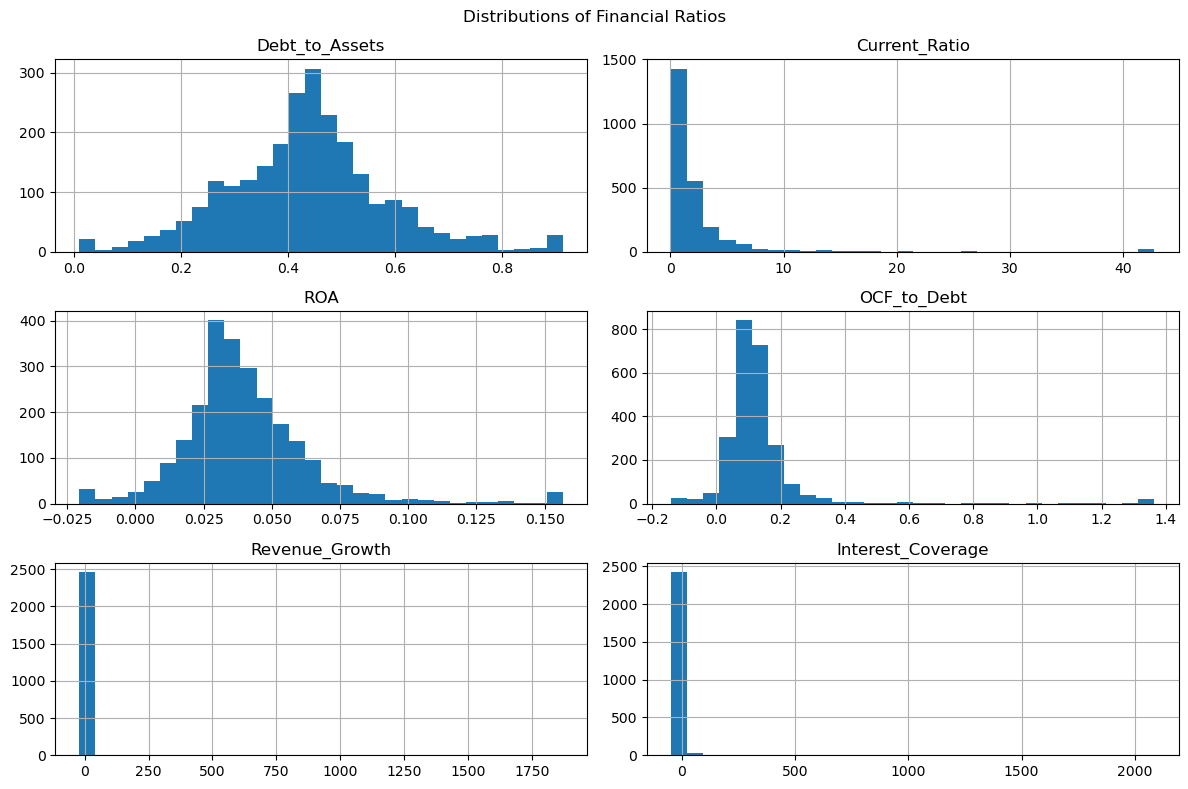

In [ ]:
df_plot.hist(figsize=(12,8), bins=30)

plt.suptitle("Distributions of Financial Ratios")
plt.tight_layout()

plt.savefig("images/feature_histograms.png", dpi=300)
plt.show()

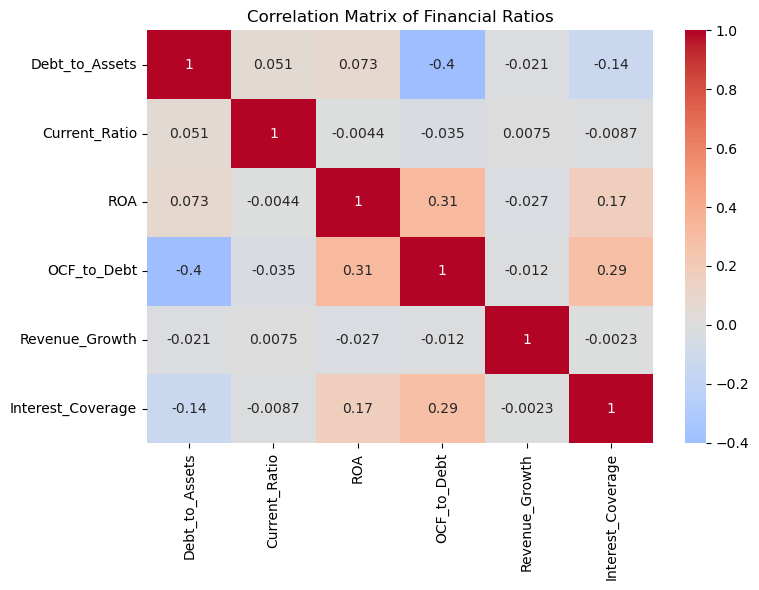

In [ ]:
corr = df_plot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Financial Ratios")

plt.tight_layout()
plt.savefig("images/correlation_matrix.png", dpi=300)
plt.show()

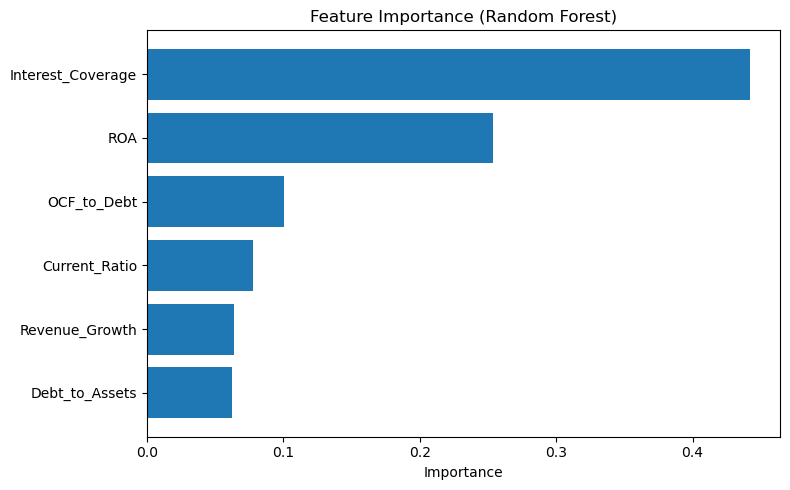

In [ ]:
importance = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300)
plt.show()

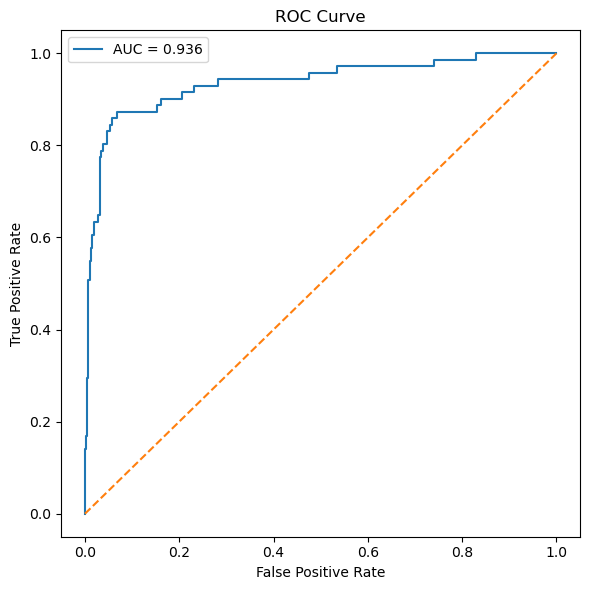

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
auc = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.tight_layout()
plt.savefig("images/roc_curve.png", dpi=300)
plt.show()

In [ ]:
distress_companies = df_final[df_final["Distress"] == 1][[
    "Company Name",
    "Exchange:Ticker",
    "Geographic Locations",
    "Primary Industry",
    "Year",
    "Forecast_Year",
    "Distress_Probability"
]]

distress_companies = distress_companies.sort_values(
    "Distress_Probability",
    ascending=False
)

distress_companies.head(20)

,Company Name,Exchange:Ticker,Geographic Locations,Primary Industry,Year,Forecast_Year,Distress_Probability
1306,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2021,2022,0.988701
1335,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,2021,2022,0.986731
2386,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2017,2018,0.981681
1605,Apartment Investment and Management Company (N...,NYSE:AIV,United States and Canada (Primary),Multi-Family Residential REITs,2020,2021,0.980540
1898,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2018,2019,0.979187
1846,"NexPoint Residential Trust, Inc. (NYSE:NXRT)",NYSE:NXRT,United States and Canada (Primary),Multi-Family Residential REITs,2019,2020,0.978565
1518,StorageVault Canada Inc. (TSX:SVI),TSX:SVI,United States and Canada (Primary),Real Estate Operating Companies,2020,2021,0.977775
2168,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2017,2018,0.977529
2438,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2016,2017,0.976474
278,"Kennedy-Wilson Holdings, Inc. (NYSE:KW)",NYSE:KW,United States and Canada (Primary),Real Estate Operating Companies,2024,2025,0.976052


In [ ]:
print(distress_companies.head(100).to_markdown(index=False))

| Company Name                                           | Exchange:Ticker    | Geographic Locations               | Primary Industry                |   Year |   Forecast_Year |   Distress_Probability |
|:-------------------------------------------------------|:-------------------|:-----------------------------------|:--------------------------------|-------:|----------------:|-----------------------:|
| NexPoint Residential Trust, Inc. (NYSE:NXRT)           | NYSE:NXRT          | United States and Canada (Primary) | Multi-Family Residential REITs  |   2021 |            2022 |               0.988701 |
| Apartment Investment and Management Company (NYSE:AIV) | NYSE:AIV           | United States and Canada (Primary) | Multi-Family Residential REITs  |   2021 |            2022 |               0.986731 |
| NexPoint Residential Trust, Inc. (NYSE:NXRT)           | NYSE:NXRT          | United States and Canada (Primary) | Multi-Family Residential REITs  |   2017 |            2018 |           